# Dynex SDK - PennyLane Native Gate Circuit Example

First we import the required packages:

In [5]:

from pennylane import numpy as np
import pennylane as qml

from dynex import DynexConfig, ComputeBackend, DynexCircuit

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model="apollo_rc1", use_notebook_output=True)



We define our circuit:

In [6]:
params = [np.pi, np.pi] # [0.1, 0.2]
wires = 2

def circuit(params):
    qml.RX(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.Hadamard(wires=0)
    return qml.state()

We draw the circuit:

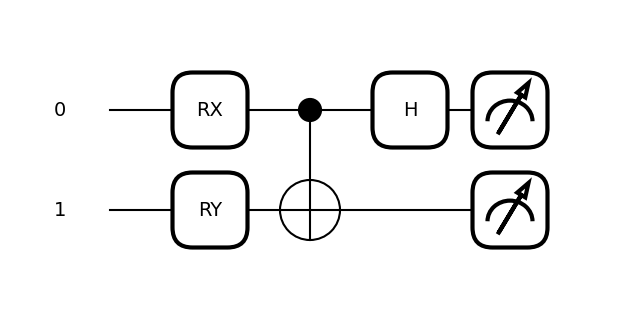

In [7]:
# draw circuit:
_ = qml.draw_mpl(circuit, style="black_white")(params)

We execute and measure the circuit on the Dynex platform:

In [ ]:
# Execute the circuit on Dynex:
dynex_circuit = DynexCircuit(config=config)

measure = dynex_circuit.execute(circuit, params, wires, method="measure", num_reads=1,
        integration_steps=10, shots=1)
print('Measure:', measure)

INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=1, shots=1, annealing_time=10
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.
INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7365)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rx_0': 6.123233995736766e-17, 'cos_ry_1': 6.123233995736766e-17, 'sin_rx_0': 1, 'sin_ry_1': 1}
INFO: [DYNEX-APOLLO-RC1] model: {'offset': '1.0', 'q': '789c8d54cb0e823010fc95de5003a4db07883f43882162e2231a0f10e3bf4b44ca2e74ad9c683b9deecc4efb5c45b75296f7ba3a45b198fed73b01a98cc577b92d8fe7ea30229a61d46312480d1805da664ae75a1676d80288111c63e228fbb98e40f697eb63c2a909f759980ec713b846cce0a3a42763be71d88314514c14748ec9b22046c3c23e1fa4a12d68830e4b42e9f18318ec6a151b31d3938064bb82608695832a55ca6426cb8b024caead5675021963bbdbb5347d5663480068b6b7242bbcdd0d9379dfad08a8f449e44943c1c3578dcdc1bcd0d6d5aaf9c6fe91

Measure: [1 0]
